# QAC388 Final Project
## Kat Basilio, Iris Chen, Marcus Leong

# Comparing twitter-roBERTa-base-sentiment labels with our human labels.

We first start with a test on a small subset, with human-labeling to test if the model's performance lines up with our expectations.

In [ ]:
from datasets import load_dataset

ds = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
for i in range(5):
    print(ds["train"][i])

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}
{'text': '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'label': 1}
{'text': 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', 'label': 1}
{'text': "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", 'label': 1}
{'text': '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"', 'label': 2}


In [ ]:
for i in range(5):
    print(f"Text: {ds['train'][i]['text']}")
    print(f"Label: {ds['train'][i]['label']}")
    print("-" * 50)

Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2
--------------------------------------------------
Text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Label: 1
--------------------------------------------------
Text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
Label: 1
--------------------------------------------------
Text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
Label: 1
--------------------------------------------------
Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Label: 2
--------------------------------------------------


# Create a small hand-labeled in-domain validation set from our own election tweets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import numpy as np
import pandas as pd

path = "/content/hashtag_donaldtrump.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head()

In [ ]:
n_sample = 300
small_sample = dt.sample(n=min(n_sample, len(dt)), random_state=42).copy()

In [ ]:
# small_sample.to_csv("small_sample.csv", index = False)

# Apply cardiffnlp model
https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment

In [ ]:
!pip -q install transformers scipy scikit-learn

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:

path = "/content/small_sample_v3.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head(20)

(300, 24)
['created_at', 'tweet_id', 'tweet', 'human_label_context', 'human_label_words_only', 'likes', 'retweet_count', 'source', 'user_id', 'user_name', 'user_screen_name', 'user_description', 'user_join_date', 'user_followers_count', 'user_location', 'lat', 'long', 'city', 'country', 'continent', 'state', 'state_code', 'collected_at', 'Unnamed: 23']


,created_at,tweet_id,tweet,human_label_context,human_label_words_only,likes,retweet_count,source,user_id,user_name,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,Unnamed: 23
0,2020-10-15 3:12:17,1.32E+18,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,0,0.0,Twitter Web App,2.153317e+09,Jim Santo,...,New York City,40.712728,-74.006015,New York,United States of America,North America,New York,NY,2020-10-21 0:17:32,NaN
1,2020-11-06 23:08:49,1.32E+18,#twitter #fakenews #DonaldTrump #JoeBiden #Ele...,1.0,1.0,0,0.0,Twitter Web App,1.060000e+18,The Mob Seat,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-07 11:19:35,NaN
2,2020-10-29 16:00:21,1.32E+18,➡️ Trump propone terminar lotería de #Visas H-...,NaN,NaN,0,0.0,App Political Hispanic,8.960000e+17,Political Hispanic,...,"Washington, DC",38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-30 14:45:53,NaN
3,2020-10-16 12:49:59,1.32E+18,#TrumpIsALaughingStock #StableGenius #trump ht...,0.0,2.0,1,0.0,Twitter Web App,1.399251e+08,darren spence,...,Jakarta,-6.175394,106.827183,Jakarta Special Capital Region,Indonesia,Asia,NaN,NaN,2020-10-21 3:17:31,NaN
4,2020-11-05 14:24:25,1.32E+18,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,0,0.0,Twitter for iPhone,4.167809e+07,Adrian Edgar,...,Warwickshire,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 9:56:43,NaN
5,2020-11-08 0:12:31,1.33E+18,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,0,0.0,Twitter Web App,7.880000e+17,The Name Is Bond,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-09 17:57:02,NaN
6,2020-11-07 18:24:20,1.33E+18,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,14,1.0,Twitter Web App,7.224311e+08,Juha Keskinen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-08 10:50:12,NaN
7,2020-11-04 19:21:09,1.32E+18,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,0,0.0,Twitter for Android,1.220000e+18,Christine Stone,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-05 12:03:09,NaN
8,2020-11-02 17:39:53,1.32E+18,@ProjectLincoln #Trump leaves a path of destru...,0.0,0.0,0,0.0,Twitter for iPhone,2.636784e+07,Midevilmack,...,Safely Indoors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-04 10:23:23,NaN
9,2020-10-26 11:15:16,1.32E+18,Trump’s attacks on voting ‘backfired and only ...,0.0,0.0,2,0.0,Twitter Web App,2.395433e+07,Hotpage News,...,United States,39.783730,-100.445882,NaN,United States,North America,NaN,NaN,2020-10-27 17:37:03,NaN


## Preprocess text


### remove short and non-english tweets

In [ ]:
!pip install lingua-language-detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 4.6 MB/s eta 0:00:00


In [ ]:
from lingua import Language, LanguageDetectorBuilder
detector = LanguageDetectorBuilder.from_all_languages().build()

In [ ]:
def remove_short_and_non_english(text):
    # Return None for very short tweets — lingua is unreliable under ~5 words
    if len(str(text).split()) < 5:
        return None

    detected = detector.detect_language_of(str(text))
    return detected == Language.ENGLISH

In [ ]:
dt['is_english'] = dt['tweet'].apply(remove_short_and_non_english)

In [ ]:
print(dt['is_english'].value_counts(dropna=False))

is_english
True     197
False     91
None      12
Name: count, dtype: int64


In [ ]:
dt_english = dt[dt['is_english'] == True].copy()

### remove urls

In [ ]:
import re

def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text).strip()

In [ ]:
dt_english['tweet_clean'] = dt_english['tweet'].apply(remove_urls)

In [ ]:
dt_english = dt_english[dt_english['tweet_clean'].str.strip() != ''].copy()
dt_english = dt_english.reset_index(drop=True)

In [ ]:
dt_english

,created_at,tweet_id,tweet,human_label_context,human_label_words_only,likes,retweet_count,source,user_id,user_name,...,long,city,country,continent,state,state_code,collected_at,Unnamed: 23,is_english,tweet_clean
0,2020-10-15 3:12:17,1.32E+18,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,0,0.0,Twitter Web App,2.153317e+09,Jim Santo,...,-74.006015,New York,United States of America,North America,New York,NY,2020-10-21 0:17:32,NaN,True,"@JoeBiden may not know it yet, but if he troun..."
1,2020-11-05 14:24:25,1.32E+18,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,0,0.0,Twitter for iPhone,4.167809e+07,Adrian Edgar,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 9:56:43,NaN,True,@davidhogg111 Do you think #Trump will get the...
2,2020-11-08 0:12:31,1.33E+18,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,0,0.0,Twitter Web App,7.880000e+17,The Name Is Bond,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-09 17:57:02,NaN,True,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...
3,2020-11-07 18:24:20,1.33E+18,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,14,1.0,Twitter Web App,7.224311e+08,Juha Keskinen,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-08 10:50:12,NaN,True,@Jason_elAvocado Yes we are! Even tho #Biden w...
4,2020-11-04 19:21:09,1.32E+18,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,0,0.0,Twitter for Android,1.220000e+18,Christine Stone,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-05 12:03:09,NaN,True,No way that #Trump/Pence2020 did not receive m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2020-11-05 4:14:22,1.32E+18,#Trump #TrumpMeltdown #Lydon Its funny that ...,0.0,0.0,0,0.0,Twitter Web App,3.230300e+09,Michael Merencky,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 10:00:38,NaN,True,#Trump #TrumpMeltdown #Lydon Its funny that ...
193,2020-10-26 13:36:20,1.32E+18,@kylegriffin1 Self preservation. He knew that...,0.0,0.0,0,0.0,Twitter Web App,1.075075e+08,Mr. Mark,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-27 17:36:38,NaN,True,@kylegriffin1 Self preservation. He knew that...
194,2020-10-24 4:34:20,1.32E+18,https://t.co/GojNMFh7Q6 \n\n#Trump #ColumbusGa...,1.0,1.0,0,1.0,Twitter Web App,2.293082e+09,Hal S. Pope,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-27 17:44:33,NaN,True,#Trump #ColumbusGa #Texas #Maralago #Doral #Tu...
195,2020-10-22 13:52:49,1.32E+18,@gopalbx @SRuhle @GovMurphy @MSNBC #ChrisChris...,0.0,0.0,4,0.0,Twitter for iPhone,1.599926e+07,tortiegertie 🐈🌸🧚‍♀️🌳🍺🥖🧀🍝🍷🍽🍫🐑📷🧶🧳,...,-74.404162,NaN,United States of America,North America,New Jersey,NJ,2020-10-27 17:56:07,NaN,True,@gopalbx @SRuhle @GovMurphy @MSNBC #ChrisChris...


### modeling on dt_english

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [ ]:
# PreTrain
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import torch
def predict_sentiment_dict(text):
  encoded_input = tokenizer(
        text,
        return_tensors="pt"
    )

  with torch.no_grad():
        output = model(**encoded_input)

  scores = output.logits[0].detach().numpy()
  probs = softmax(scores)

  prob_dict = {
        labels[i]: float(probs[i]) for i in range(len(labels))
    }

  return prob_dict

In [ ]:
dt_english["sentiment_probs"] = dt_english["tweet"].apply(predict_sentiment_dict)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs"]].head()

,tweet,human_label_context,human_label_words_only,sentiment_probs
0,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,"{'negative': 0.04322223737835884, 'neutral': 0..."
1,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,"{'negative': 0.24181526899337769, 'neutral': 0..."
2,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,"{'negative': 0.764579176902771, 'neutral': 0.2..."
3,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,"{'negative': 0.46058905124664307, 'neutral': 0..."
4,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,"{'negative': 0.7577735185623169, 'neutral': 0...."


In [ ]:
def get_top_label(prob_dict):
    return max(prob_dict, key=prob_dict.get)

dt_english["sentiment_label"] = dt_english["sentiment_probs"].apply(get_top_label)

In [ ]:
label_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

dt_english["sentiment_label_id"] = dt_english["sentiment_label"].map(label_to_id)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs", 'sentiment_label', 'sentiment_label_id']].head()

,tweet,human_label_context,human_label_words_only,sentiment_probs,sentiment_label,sentiment_label_id
0,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,"{'negative': 0.04322223737835884, 'neutral': 0...",positive,2
1,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,"{'negative': 0.24181526899337769, 'neutral': 0...",neutral,1
2,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,"{'negative': 0.764579176902771, 'neutral': 0.2...",negative,0
3,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,"{'negative': 0.46058905124664307, 'neutral': 0...",negative,0
4,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,"{'negative': 0.7577735185623169, 'neutral': 0....",negative,0


In [ ]:
# dt_english.to_csv("dt_english_predicted.csv", index = False)

### Confusion matrix

In [ ]:
dt_english['human_label_context'] = dt_english['human_label_context'].astype(int)
dt_english['sentiment_label_id'] = dt_english['sentiment_label_id'].astype(int)

              precision    recall  f1-score   support

    positive       0.45      0.30      0.36        44
     neutral       0.54      0.65      0.59        55
    negative       0.76      0.79      0.77        98

    accuracy                           0.64       197
   macro avg       0.58      0.58      0.57       197
weighted avg       0.63      0.64      0.63       197



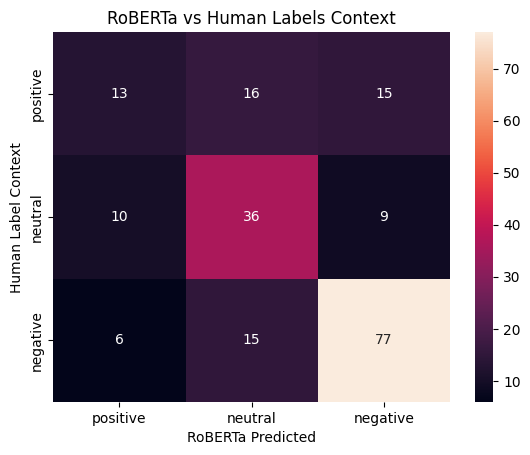

Cohen's kappa: 0.415991649269311


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Context')
plt.title('RoBERTa vs Human Labels Context')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id']
))

              precision    recall  f1-score   support

    positive       0.62      0.50      0.55        36
     neutral       0.64      0.66      0.65        65
    negative       0.81      0.85      0.83        96

    accuracy                           0.73       197
   macro avg       0.69      0.67      0.68       197
weighted avg       0.72      0.73      0.72       197



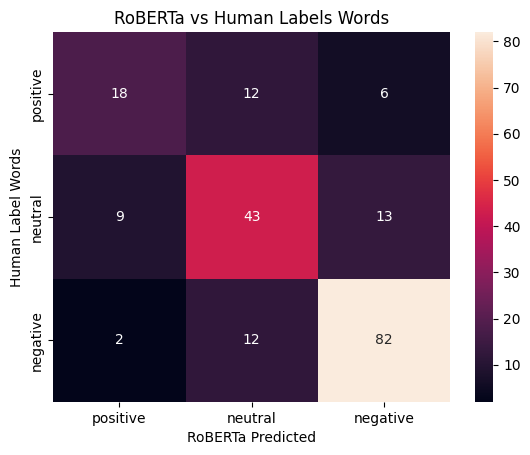

Cohen's kappa: 0.5514042337859493


In [ ]:
print(classification_report(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Words')
plt.title('RoBERTa vs Human Labels Words')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id']
))

# Data Preprocessing
## This is the true start of our analysis work past the human labeling test.

In [ ]:
import pandas as pd

In [ ]:
biden = pd.read_csv("/content/hashtag_joebiden.csv")

/tmp/ipykernel_1820/2202882825.py:1: DtypeWarning: Columns (1,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  biden = pd.read_csv("/content/hashtag_joebiden.csv")


In [ ]:
biden.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at
0,2020-10-15 00:00:01,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,360666534.0,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,1860.0,"Philadelphia, PA / Miami, FL",25.77427,-80.19366,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00
1,2020-10-15 00:00:18,1.31652929585929e+18,#HunterBiden #HunterBidenEmails #JoeBiden #Joe...,0.0,0.0,Twitter for iPad,809904438.0,Cheri A. 🇺🇸,Biloximeemaw,"Locked and loaded Meemaw. Love God, my family ...",...,6628.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.517827283
2,2020-10-15 00:00:20,1.3165293050069524e+18,@IslandGirlPRV @BradBeauregardJ @MeidasTouch T...,0.0,0.0,Twitter Web App,3494182277.0,Flag Waver,Flag_Wavers,NaN,...,1536.0,Golden Valley Arizona,46.304036,-109.171431,NaN,United States of America,North America,Montana,MT,2020-10-21 00:00:01.035654566
3,2020-10-15 00:00:21,1.3165293080815575e+18,@chrislongview Watching and setting dvr. Let’s...,0.0,0.0,Twitter for iPhone,8.242596012018524e+17,Michelle Ferg,MichelleFerg4,NaN,...,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.553481849
4,2020-10-15 00:00:22,1.316529312741253e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032806955356545e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,390.0,"California, USA",36.701463,-118.755997,NaN,United States of America,North America,California,CA,2020-10-21 00:00:02.071309132


In [ ]:
trump = pd.read_csv("/content/hashtag_donaldtrump.csv", engine="python")

In [ ]:
trump.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at
0,2020-10-15 00:00:01,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,360666534.0,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,1860.0,"Philadelphia, PA / Miami, FL",25.77427,-80.19366,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00
1,2020-10-15 00:00:01,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,Social Mediaset,331617619.0,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,1067661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530
2,2020-10-15 00:00:02,1.316529228091847e+18,"#Trump: As a student I used to hear for years,...",2.0,1.0,Twitter Web App,8436472.0,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,1185.0,Portland,45.5202471,-122.6741949,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060
3,2020-10-15 00:00:02,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.0,Trumpytweeter,8.28355589206057e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591
4,2020-10-15 00:00:08,1.3165292523014513e+18,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,Twitter for iPhone,47413798.0,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,5393.0,Washington DC,38.8949924,-77.0365581,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121


In [ ]:
merged = pd.concat([biden, trump], ignore_index=True)

# Remove duplicates based on a specific column, keeping the first occurrence
merged = merged.drop_duplicates(subset=["tweet_id"], keep="first")

# reset index after dedup
merged = merged.reset_index(drop=True)

# Save result
merged.to_csv("merged_output.csv", index=False)

In [ ]:
merged = pd.read_csv("merged_output.csv")

/tmp/ipykernel_7316/1866028101.py:1: DtypeWarning: Columns (1,3,6,11) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("merged_output.csv")


In [ ]:
len(merged)

1553468

In [ ]:
merged["likes"] = pd.to_numeric(merged["likes"], errors='coerce')
merged = merged[(merged["likes"] != 0) & merged["likes"].notna()]

In [ ]:
len(merged)

689819

with na: 689866
without na: 689819

In [ ]:
!pip install lingua-language-detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 15.1 MB/s eta 0:00:00


In [ ]:
from lingua import Language, LanguageDetectorBuilder
detector = LanguageDetectorBuilder.from_all_languages().build()

In [ ]:
def remove_short_and_non_english(text):
    # Return None for very short tweets — lingua is unreliable under ~5 words
    if len(str(text).split()) < 5:
        return None

    detected = detector.detect_language_of(str(text))
    return detected == Language.ENGLISH

In [ ]:
merged['is_english'] = merged['tweet'].apply(remove_short_and_non_english)

In [ ]:
print(merged['is_english'].value_counts(dropna=False))

NameError: name 'merged' is not defined

In [ ]:
merged_english = merged[merged['is_english'] == True].copy()

NameError: name 'merged' is not defined

In [ ]:
merged_english = pd.read_csv("/content/merged_english.csv")

In [ ]:
import re

def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text).strip()

In [ ]:
merged_english['tweet_clean'] = merged_english['tweet'].apply(remove_urls)

In [ ]:
merged_english = merged_english[merged_english['tweet_clean'].str.strip() != ''].copy()
merged_english = merged_english.reset_index(drop=True)

In [ ]:
len(merged_english)

396589

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
merged_english.to_csv("merged_english.csv", index=False)

NameError: name 'merged_english' is not defined

In [ ]:
merged_english.columns

Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at', 'is_english', 'tweet_clean'],
      dtype='object')

In [ ]:
print(merged_english["user_followers_count"].dtype)

float64


Calculate engagement score

In [ ]:
import numpy as np

In [ ]:
merged_english["user_followers_count"] = pd.to_numeric(merged_english["user_followers_count"], errors='coerce')

In [ ]:
merged_english['E_raw'] = (merged_english['likes'] + 2 * merged_english['retweet_count']) / (merged_english['user_followers_count'] + 1)
merged_english['E_log'] = np.log1p(merged_english['E_raw'])
log_min = merged_english['E_log'].min()
log_max = merged_english['E_log'].max()
merged_english['E_score'] = (merged_english['E_log'] - log_min) / (log_max - log_min)

In [ ]:
merged_english.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,country,continent,state,state_code,collected_at,is_english,tweet_clean,E_raw,E_log,E_score
0,2020-10-15 00:00:22,1.316529e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032807e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,United States of America,North America,California,CA,2020-10-21 00:00:02.071309132,True,#censorship #HunterBiden #Biden #BidenEmails #...,0.002558,0.002554,0.000386
1,2020-10-15 00:00:41,1.316529e+18,Proof Bidens are crooked. Twitter will suspen...,1.0,1.0,Twitter for Android,1.275659e+18,Jake Rivendale,JakeRivendale,NaN,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:04.660445547,True,Proof Bidens are crooked. Twitter will suspen...,0.037037,0.036368,0.005494
2,2020-10-15 00:01:16,1.316530e+18,@tedcruz @cc125 #Trump2020 #BLM #obama #VoteRe...,1.0,0.0,Twitter Web App,1.310040e+18,Infamous One,InfamousOne13,"""The company you keep can have a major impact ...",...,NaN,NaN,NaN,NaN,2020-10-21 00:00:07.249581962,True,@tedcruz @cc125 #Trump2020 #BLM #obama #VoteRe...,0.002770,0.002766,0.000418
3,2020-10-15 00:01:20,1.316530e+18,#IceCube isn’t a sellout how long are black pe...,1.0,1.0,Twitter for iPhone,2.851319e+08,𝓐𝓵𝓮𝔁𝓲𝓪 𝓜𝓪𝓻𝓲𝓮𝓮🧘🏾‍♀️🦋✨,alexiamariee_,snap: 𝒜𝓁𝑒𝓍𝒾𝒶𝓂𝒶𝓇𝒾𝑒𝟤𝟨 ig: 𝒜𝓁𝑒𝓍𝒾𝒶𝓂𝒶𝓇𝒾𝑒𝑒. 🕊🙏🏾Kavou...,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:08.285236528,True,#IceCube isn’t a sellout how long are black pe...,0.005146,0.005133,0.000775
4,2020-10-15 00:01:20,1.316530e+18,BREAKING — Twitter Safety account provides inf...,1.0,1.0,Twitter for iPhone,1.247223e+18,Insider Paper,TheInsiderPaper,Insider Paper is your source to real news from...,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:07.767409245,True,BREAKING — Twitter Safety account provides inf...,0.002498,0.002495,0.000377


In [ ]:
merged_english["country"].unique()

array(['United States of America', nan, 'United Kingdom', 'Poland',
       'United States', 'Spain', 'Egypt', 'Jersey', 'Canada', 'Australia',
       'Mongolia', 'Costa Rica', 'Japan', 'South Korea', 'Greece',
       'Turkey', 'Malaysia', 'Georgia', 'New Zealand', 'Slovenia',
       'India', 'The Netherlands', 'Venezuela', 'China',
       'United Arab Emirates', 'Iran', 'Italy', 'France', 'Bangladesh',
       'Finland', 'Cambodia', 'Luxembourg', 'Belgium', 'Germany',
       'Uganda', 'Pakistan', 'Hungary', 'Netherlands', 'Switzerland',
       'Sweden', 'Philippines', 'Singapore', 'Mexico', 'Fiji', 'Austria',
       'Norway', 'Bahrain', 'Ireland', 'Israel', 'Chile', 'Estonia',
       'South Africa', 'Liberia', 'Vietnam', 'Armenia', 'Latvia',
       'Tunisia', 'Serbia', 'Colombia', 'Azerbaijan', 'Qatar', 'Taiwan',
       'Denmark', 'Ethiopia', 'Peru', 'Cuba', 'Russia', 'Lebanon',
       'Indonesia', 'Barbados', 'Argentina', 'Panama', 'Saudi Arabia',
       'Kenya', 'Iceland', 'Tanzania',

In [ ]:
((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")).sum()

np.int64(121516)

In [ ]:
merged_english["created_at"][83855]

'2020-11-02 17:17:17'

In [ ]:
df = merged_english[((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")) & (merged_english["state"].notna())]

In [ ]:
len(df)

104207

In [ ]:
import pandas as pd

In [ ]:
print(df['state'].value_counts())

state
California              15952
New York                12694
Texas                    8308
Florida                  7540
District of Columbia     5002
Illinois                 3603
Pennsylvania             3512
New Jersey               2492
Massachusetts            2305
Ohio                     1972
Oregon                   1809
North Carolina           1749
Michigan                 1722
Arizona                  1681
Georgia                  1656
Colorado                 1603
Virginia                 1412
Nevada                   1398
Washington               1266
Maryland                 1172
Tennessee                1121
Minnesota                1025
Missouri                  922
Wisconsin                 828
Kentucky                  773
South Carolina            699
Indiana                   677
Louisiana                 666
Kansas                    573
Alabama                   513
Connecticut               510
Oklahoma                  485
Iowa                      458
Hawa

Remove Guam and Northern Mariana Islands due to the very small counts (1 and 2 respectively)

In [ ]:
df = df[(df['state'] != "Guam") & (df['state'] != "Northern Mariana Islands")]
print(df['state'].value_counts())

state
California              15952
New York                12694
Texas                    8308
Florida                  7540
District of Columbia     5002
Illinois                 3603
Pennsylvania             3512
New Jersey               2492
Massachusetts            2305
Ohio                     1972
Oregon                   1809
North Carolina           1749
Michigan                 1722
Arizona                  1681
Georgia                  1656
Colorado                 1603
Virginia                 1412
Nevada                   1398
Washington               1266
Maryland                 1172
Tennessee                1121
Minnesota                1025
Missouri                  922
Wisconsin                 828
Kentucky                  773
South Carolina            699
Indiana                   677
Louisiana                 666
Kansas                    573
Alabama                   513
Connecticut               510
Oklahoma                  485
Iowa                      458
Hawa

Final dataset:
- English only
- In the US
- State not NA

# Sentiment analysis

Run df through TwitterRobertaBaseSentiment to get the sentiment classifications of the tweets

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL).to(device)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import DataLoader

tweets = df["tweet"].astype(str).tolist()

# Tokenize everything at once (returns tensors)
# padding=True and truncation=True make sure all tensors are the same shape
inputs = tokenizer(tweets, padding=True, truncation=True, return_tensors="pt", max_length=128)

# Create a DataLoader to feed the GPU in chunks
dataset = torch.utils.data.TensorDataset(inputs['input_ids'], inputs['attention_mask'])
loader = DataLoader(dataset, batch_size=32)

# Predict in a loop
model.eval()
model.to(device)
all_logits = []

with torch.no_grad():
    for batch in loader:
        b_input_ids, b_attn_mask = [t.to(device) for t in batch]
        outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask)
        all_logits.append(outputs.logits.cpu())

# Concatenate results and get labels
final_logits = torch.cat(all_logits, dim=0)
probs = torch.nn.functional.softmax(final_logits, dim=-1)

# Convert the probabilities tensor to a NumPy array
probs_np = probs.numpy()

# Add the raw probabilities to dataframe
df["sentiment_probs"] = probs_np.tolist()

# map to labels (labels obtained from the model itself)
indices = np.argmax(probs_np, axis=1)
df["sentiment_label"] = [labels[i] for i in indices]

KeyboardInterrupt: 

In [ ]:
df.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,state,state_code,collected_at,is_english,tweet_clean,E_raw,E_log,E_score,sentiment_probs,sentiment_label
0,2020-10-15 00:00:22,1.316529e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032807e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,California,CA,2020-10-21 00:00:02.071309132,True,#censorship #HunterBiden #Biden #BidenEmails #...,0.002558,0.002554,0.000386,"[0.6924492120742798, 0.2935495674610138, 0.014...",negative
1,2020-10-15 00:01:42,1.316530e+18,In an effort to find the truth about allegatio...,1.0,0.0,Twitter Web App,1.165118e+18,The Big Homie,_dbrown_23,#YAHDOG Posse's Top Guy.\n@illinivideo\n@Illin...,...,Illinois,IL,2020-10-21 00:00:10.874372943,True,In an effort to find the truth about allegatio...,0.001047,0.001047,0.000158,"[0.4220110774040222, 0.5309473276138306, 0.047...",neutral
2,2020-10-15 00:01:47,1.316530e+18,Twitter is doing everything they can to help D...,1.0,0.0,Twitter for iPhone,1.139962e+18,Wynward,Joelwhct,NaN,...,California,CA,2020-10-21 00:00:11.392200226,True,Twitter is doing everything they can to help D...,0.333333,0.287682,0.043461,"[0.3415294289588928, 0.4945909082889557, 0.163...",neutral
3,2020-10-15 00:02:35,1.316530e+18,A simple question. Who are you voting for? #20...,1.0,1.0,Twitter for Android,8.957270e+17,John MacDonald for the People,jmac4thepeople,"Father, veteran, veteran's advocate, former ca...",...,Massachusetts,MA,2020-10-21 00:00:19.159609471,True,A simple question. Who are you voting for? #20...,0.002392,0.002389,0.000361,"[0.055623218417167664, 0.8585494160652161, 0.0...",neutral
4,2020-10-15 00:02:50,1.316530e+18,Has this awoken you from your slumbers yet @BB...,1.0,0.0,Twitter for iPhone,5.667098e+07,malcolm cowing,MalcolmCowing,Retired former Managing Partner of marcoms age...,...,Virginia,VA,2020-10-21 00:00:21.748745887,True,Has this awoken you from your slumbers yet @BB...,0.000741,0.000740,0.000112,"[0.7433387041091919, 0.23445509374141693, 0.02...",negative


In [ ]:
df.to_csv("df.csv", index=False)

## We can start from here if importing ***df.csv***
### This was a checkpoint for us to avoid having to re-run all the preprocessing steps.

In [ ]:
df = pd.read_csv("/content/df.csv")

In [ ]:
len(df)

92213

# Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Average engagement score by state
engagement_by_state = df.groupby('state')['E_score'].mean().sort_values(ascending=False)

# Sentiment distribution by state — proportion of each label
sentiment_by_state = df.groupby('state')['sentiment_label'].value_counts(normalize=True).unstack(fill_value=0)

# Most common sentiment per state
dominant_sentiment = df.groupby('state')['sentiment_label'].agg(lambda x: x.value_counts().index[0])

# Combine into one summary table
summary = pd.DataFrame({
    'avg_engagement_score': engagement_by_state,
    'dominant_sentiment': dominant_sentiment,
    'pct_positive': sentiment_by_state.get('positive', 0),
    'pct_neutral': sentiment_by_state.get('neutral', 0),
    'pct_negative': sentiment_by_state.get('negative', 0),
    'tweet_count': df.groupby('state').size()
})

print(summary.sort_values('avg_engagement_score', ascending=False).to_string())

# Filter the summary DataFrame
filtered_summary = summary[summary['tweet_count'] > 500]

# Print the filtered result
print(filtered_summary.sort_values('avg_engagement_score', ascending=False).to_string())

                      avg_engagement_score dominant_sentiment  pct_positive  pct_neutral  pct_negative  tweet_count
state                                                                                                              
Rhode Island                      0.006943           negative      0.194631     0.328859      0.476510          149
West Virginia                     0.006322           negative      0.245810     0.273743      0.480447          179
Alabama                           0.005657           negative      0.157895     0.321637      0.520468          513
Wyoming                           0.005655           negative      0.213592     0.233010      0.553398          103
Wisconsin                         0.005165           negative      0.245169     0.315217      0.439614          828
Michigan                          0.004935           negative      0.213124     0.324042      0.462834         1722
Indiana                           0.004901           negative      0.228

# Baseline models for comparison

Baseline model 1:
- Input: user_id

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
df = df.dropna(subset=['user_followers_count']).copy()

In [ ]:
len(df)

92213

In [ ]:
df['log_followers_count'] = np.log1p(df['user_followers_count'])

In [ ]:
y = df['E_score']
X = df[['log_followers_count']]

In [ ]:
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

In [ ]:
df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]

In [ ]:
# Compute mean engagement per user from training set only
user_mean_map = df_train.groupby('user_id')['E_score'].mean()
global_mean = y_train.mean()

# Map mean engagement onto each split
df_train['user_mean_engagement'] = df_train['user_id'].map(user_mean_map)
df_val['user_mean_engagement'] = df_val['user_id'].map(user_mean_map).fillna(global_mean)

# Train baseline
X_train_user = df_train[['user_mean_engagement']]
X_val_user = df_val[['user_mean_engagement']]

baseline_user = LinearRegression()
baseline_user.fit(X_train_user, y_train)

preds_user = baseline_user.predict(X_val_user)

print("User ID baseline:")
print(f"R²:   {r2_score(y_val, preds_user):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds_user):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds_user)):.4f}")

# Check how many unseen users got the global mean fallback
unseen = ~df_val['user_id'].isin(user_mean_map.index)
print(f"\nUnseen users in val: {unseen.sum()} ({unseen.mean():.1%})")

User ID baseline:
R²:   0.0766
MAE:  0.0032
RMSE: 0.0145

Unseen users in val: 4020 (27.2%)


27.2% of validation users were unseen in training and received global mean predictions, which likely underestimates the true predictive power of user identity

Baseline model 2:
- Input: follower count

In [ ]:
# Single feature — reshape needed for sklearn
X_train_followers = X_train[['log_followers_count']]
X_val_followers = X_val[['log_followers_count']]

baseline_followers = LinearRegression()
baseline_followers.fit(X_train_followers, y_train)

preds = baseline_followers.predict(X_val_followers)

print("Follower count baseline:")
print(f"R²:   {r2_score(y_val, preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds)):.4f}")

Follower count baseline:
R²:   0.1442
MAE:  0.0053
RMSE: 0.0140


With the baseline models showing **0.0766** and **0.1442** for their R^2 scores, this is what we need to beat in our model.

# Feature Engineering

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained('Twitter/twhin-bert-base')
model = AutoModel.from_pretrained('Twitter/twhin-bert-base')
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def get_embeddings(texts, batch_size=64):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt',
                          truncation=True, max_length=128, padding=True)

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # Mean pooling — average over all non-padding tokens
        # Get the attention_mask that was set when we tokenized the input
        attention_mask = inputs['attention_mask']
        # Get the actual token embeddings that resulted from passing the input through the model
        token_embeddings = outputs.last_hidden_state

        # Expand mask to match embedding dimensions
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        # Sum embeddings where mask=1, divide by number of real tokens
        # By multiplying, we remove tokens part of the mask, then we sum all tokens to get one embedding per tweet
        sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
        # Sum the number of real (non-padding) tokens
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        mean_embeddings = sum_embeddings / sum_mask

        all_embeddings.append(mean_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

embeddings = get_embeddings(df['tweet_clean'].tolist())
np.save('twhin_embeddings.npy', embeddings)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Twitter/twhin-bert-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.distance_embedding.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight                               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias                             | UNEXPECTED | 
cls.predictions.bias                                                 | UNEXPECTED | 
cls.predictions.transform.dense.bias                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                           | UNEXPECTED | 
bert.embeddings.position_ids                                         | UNEXPECTED | 
pooler.dense.bias                                                    | MISSING    | 
pooler.dense.weight                                                  | MISSING    | 

Notes:
- UNE

In [ ]:
from datetime import datetime
df["created_at"] = pd.to_datetime(df["created_at"], format="%Y-%m-%d %H:%M:%S")
df["user_join_date"] = pd.to_datetime(df["user_join_date"], format="%Y-%m-%d %H:%M:%S")
df["account_age"] = (df["created_at"] - df["user_join_date"]).dt.days
df["log_account_age"] = np.log1p(df["account_age"])

election_date = pd.Timestamp("2020-11-03")
df["days_before_election"] = (election_date - df["created_at"]).dt.days
print(df["days_before_election"].describe())

count    92213.000000
mean         5.071226
std          7.331601
min         -6.000000
25%         -2.000000
50%          5.000000
75%         11.000000
max         18.000000
Name: days_before_election, dtype: float64


In [ ]:
counts = df['source'].value_counts()

# Identify categories with less than 3000 occurrences
repl = counts[counts < 3000].index

# Replace those categories with "Others"
df['source'] = df['source'].replace(repl, 'Others')

In [ ]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['E_score']

X = df.copy()

# First split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Then split remainder into train (80%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Now get the df splits
df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]
df_test = df.loc[X_test.index]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 59016, Val: 14754, Test: 18443


In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['log_account_age', 'days_before_election']

scaler = StandardScaler()
continuous_train = scaler.fit_transform(df_train[continuous_cols])
continuous_val = scaler.transform(df_val[continuous_cols])
continuous_test = scaler.transform(df_test[continuous_cols])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

source_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
source_train = source_encoder.fit_transform(df_train[['source']])
source_val = source_encoder.transform(df_val[['source']])
source_test = source_encoder.transform(df_test[['source']])

In [ ]:
sentiment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
sentiment_train = sentiment_encoder.fit_transform(df_train[['sentiment_label']])
sentiment_val = sentiment_encoder.transform(df_val[['sentiment_label']])
sentiment_test = sentiment_encoder.transform(df_test[['sentiment_label']])

In [ ]:
# Create integer mapping
state_categories = df['state'].unique().tolist()
state_map = {state: idx for idx, state in enumerate(state_categories)}

state_train = df_train['state'].map(state_map).fillna(0).astype(int).values
state_val = df_val['state'].map(state_map).fillna(0).astype(int).values
state_test = df_test['state'].map(state_map).fillna(0).astype(int).values

num_states = len(state_map)

In [ ]:
all_embeddings = np.load('twhin_embeddings.npy')
label_to_pos = {label: pos for pos, label in enumerate(df.index)}

train_positions = [label_to_pos[i] for i in df_train.index]
val_positions = [label_to_pos[i] for i in df_val.index]
test_positions = [label_to_pos[i] for i in df_test.index]

emb_train = all_embeddings[train_positions]
emb_val = all_embeddings[val_positions]
emb_test = all_embeddings[test_positions]

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                 sentiment_onehot, state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

In [ ]:
train_dataset = TweetDataset(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset = TweetDataset(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset = TweetDataset(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
df["state"].unique()

array(['California', 'Illinois', 'Massachusetts', 'Virginia', 'New York',
       'Washington', 'Maryland', 'New Jersey', 'Montana',
       'South Carolina', 'Texas', 'Utah', 'Florida', 'North Carolina',
       'Pennsylvania', 'Arizona', 'Oregon', 'District of Columbia',
       'Oklahoma', 'New Mexico', 'Ohio', 'Kentucky', 'Nevada', 'Colorado',
       'Minnesota', 'Michigan', 'Idaho', 'Wisconsin', 'North Dakota',
       'Missouri', 'Georgia', 'Alabama', 'Arkansas', 'Tennessee', 'Maine',
       'Kansas', 'Hawaii', 'Indiana', 'Alaska', 'New Hampshire',
       'Louisiana', 'Mississippi', 'Iowa', 'Connecticut', 'West Virginia',
       'Puerto Rico', 'Rhode Island', 'Nebraska', 'Delaware', 'Vermont',
       'Wyoming', 'South Dakota'], dtype=object)

# Model setup

In [ ]:
import torch
import torch.nn as nn

class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + \
                       sentiment_train.shape[1] + state_emb_dim
        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        # Build layers dynamically
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                sentiment_onehot, state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot,
            sentiment_onehot, state_emb
        ], dim=1)
        return self.network(combined).squeeze()

In [ ]:
!pip install optuna

In [ ]:
import optuna
from optuna.trial import Trial
from sklearn.metrics import r2_score

def objective(trial):
    # Architecture, we are also adding the number of layers as a hyperparameter to be determined
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256, 512, 1024])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])

    # Optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)

    # Training
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Activation function
    activation = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    # Build model dynamically based on n_layers
    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        activation=activation,
        num_states=num_states
    ).to(device)

    # Select optimizer
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    # select loss, Huber is a mix between MSE and MAE
    loss_name = trial.suggest_categorical('loss', ['MSE', 'MAE', 'Huber'])

    if loss_name == 'MSE':
      criterion = nn.MSELoss()
    elif loss_name == 'MAE':
      criterion = nn.L1Loss()
    elif loss_name == 'Huber':
      criterion = nn.HuberLoss(delta=0.1)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_preds.extend(preds.cpu().numpy())

    # compare on R^2 score, not the different losses
    return r2_score(y_val.values, val_preds)

# Run the study
study = optuna.create_study(direction='maximize')  # maximize R²
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)
print(f"Best val R²: {study.best_value:.4f}")

[I 2026-05-09 23:22:51,210] A new study created in memory with name: no-name-2e5e0477-fd5a-42a6-be22-9d4d16a532c2
[I 2026-05-09 23:23:15,178] Trial 0 finished with value: -0.00399848878947795 and parameters: {'n_layers': 3, 'hidden_dim_0': 1024, 'hidden_dim_1': 256, 'hidden_dim_2': 1024, 'dropout': 0.24453648461034452, 'use_layernorm': False, 'optimizer': 'RMSprop', 'lr': 3.959111414562303e-06, 'weight_decay': 3.228863036202022e-05, 'batch_size': 128, 'activation': 'leaky_relu', 'loss': 'MAE'}. Best is trial 0 with value: -0.00399848878947795.
[I 2026-05-09 23:23:53,267] Trial 1 finished with value: 0.041781021840428645 and parameters: {'n_layers': 4, 'hidden_dim_0': 512, 'hidden_dim_1': 256, 'hidden_dim_2': 256, 'hidden_dim_3': 512, 'dropout': 0.2145233312753006, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 0.0019830919800603404, 'weight_decay': 0.00019091153751433075, 'batch_size': 64, 'activation': 'leaky_relu', 'loss': 'Huber'}. Best is trial 1 with value: 0.0417810218404286

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

best_params = study.best_params

# Create dataloaders with best batch size
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

# Build final model with best hyperparameters
final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    activation=best_params['activation'],
    num_states=num_states
).to(device)

# Select best optimizer
if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

# Select best loss
if best_params['loss'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss'] == 'MAE':
    criterion = nn.L1Loss()
elif best_params['loss'] == 'Huber':
    criterion = nn.HuberLoss(delta=0.1)

# Track per epoch for plotting
train_losses_per_epoch = []
val_losses_per_epoch = []
val_r2_per_epoch = []

best_val_r2 = float('-inf')  # note: was float('inf') before which was a bug

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        preds = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(preds, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            preds = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_losses.append(criterion(preds, batch['target'].to(device)).item())
            val_preds.extend(preds.cpu().numpy())

    val_r2 = r2_score(y_val.values, val_preds)
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_r2_per_epoch.append(val_r2)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val R²: {val_r2:.4f}")

    # Save best model based on R²
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        torch.save(final_model.state_dict(), 'best_model.pt')
        print(f"  → New best model saved (R²={val_r2:.4f})")

print(f"\nTraining complete. Best val R²: {best_val_r2:.4f}")

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, 51)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(epochs, train_losses_per_epoch, label='Train Loss')
ax1.plot(epochs, val_losses_per_epoch, linestyle='-.', label='Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# R² plot
ax2.plot(epochs, val_r2_per_epoch, label='Val R²', color='green')
ax2.axhline(y=max(val_r2_per_epoch), color='red', linestyle='--',
            label=f'Best R²={max(val_r2_per_epoch):.4f}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('R²')
ax2.set_title('Validation R² per Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Load best model
final_model.load_state_dict(torch.load('best_model.pt'))
final_model.eval()

test_dataset = TweetDataset(
    embeddings=all_embeddings[X_test.index],
    continuous_meta=scaler.transform(df_test[continuous_cols]),
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)
test_loader = DataLoader(test_dataset, batch_size=64)

test_preds = []
with torch.no_grad():
    for batch in test_loader:
        preds = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds.extend(preds.cpu().numpy())

print("Test Results:")
print(f"R²:   {r2_score(y_test, test_preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, test_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

On the test set, we see that our model's R^2 is **0.0590**, worse than the 2 baselines models.

# Taking engagement as a categorical variable instead

Plot to determine threshold (or decide manually)

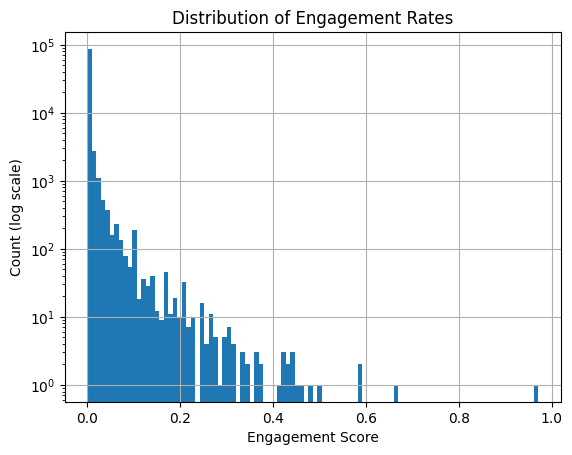

count    9.221300e+04
mean     3.448079e-03
std      1.614339e-02
min      1.105968e-07
25%      1.115728e-04
33%      1.667035e-04
50%      3.790608e-04
66%      8.369285e-04
75%      1.431940e-03
90%      5.534389e-03
95%      1.314504e-02
99%      6.125484e-02
max      9.704851e-01
Name: E_score, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

df['E_score'].hist(bins=100, log=True)
plt.xlabel('Engagement Score')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Engagement Rates')
plt.show()

# Also look at percentiles to understand the distribution
print(df['E_score'].describe(percentiles=[.25, .33, .5, .66, .75, .90, .95, .99]))

Since there is a very skewed distribution and no natural breakpoints, we will use ***pd.qcut*** to equally distribute based on the engagement score.

In [ ]:
df['engagement_label'] = pd.qcut(
    df['E_score'],
    q = 3,
    labels=[0, 1, 2]  # 0=low, 1=mid, 2=high
)

print(df['engagement_label'].value_counts().sort_index())
df['engagement_label'] = df['engagement_label'].astype(int)

engagement_label
0    30747
1    30751
2    30715
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=['user_followers_count']).copy()
df['log_followers_count'] = np.log1p(df['user_followers_count'])

In [ ]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['engagement_label'].astype(int)

X = df.copy()

# First split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Then split remainder into train (80%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Now get the df splits
df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]
df_test = df.loc[X_test.index]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 59016, Val: 14754, Test: 18443


Baseline models (same as in linear regression):

In [ ]:
# Compute mean engagement per user from training set only
user_mean_map = df_train.groupby('user_id')['E_score'].mean()
global_mean = df_train['E_score'].mean()

df_train['user_mean_engagement'] = df_train['user_id'].map(user_mean_map)
df_val['user_mean_engagement'] = df_val['user_id'].map(user_mean_map).fillna(global_mean)

X_train_user = df_train[['user_mean_engagement']]
X_val_user = df_val[['user_mean_engagement']]

baseline_user = LogisticRegression(max_iter=1000)
baseline_user.fit(X_train_user, y_train)

preds_user = baseline_user.predict(X_val_user)

print("User ID baseline:")
print(classification_report(y_val, preds_user, target_names=['low', 'mid', 'high']))
print(f"Weighted F1: {f1_score(y_val, preds_user, average='weighted'):.4f}")

unseen = ~df_val['user_id'].isin(user_mean_map.index)
print(f"\nUnseen users in val: {unseen.sum()} ({unseen.mean():.1%})")

User ID baseline:
              precision    recall  f1-score   support

         low       0.47      0.85      0.61      5024
         mid       0.29      0.02      0.04      4902
        high       0.61      0.68      0.65      4828

    accuracy                           0.52     14754
   macro avg       0.46      0.52      0.43     14754
weighted avg       0.46      0.52      0.43     14754

Weighted F1: 0.4315

Unseen users in val: 4020 (27.2%)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Use the same log_followers_count feature
X_train_followers = df_train[['log_followers_count']]
X_val_followers = df_val[['log_followers_count']]

baseline_followers = LogisticRegression(max_iter=1000)
baseline_followers.fit(X_train_followers, y_train)

preds_followers = baseline_followers.predict(X_val_followers)

print("Follower count baseline:")
print(classification_report(y_val, preds_followers, target_names=['low', 'mid', 'high']))
print(f"Weighted F1: {f1_score(y_val, preds_followers, average='weighted'):.4f}")

Follower count baseline:
              precision    recall  f1-score   support

         low       0.68      0.67      0.67      5024
         mid       0.50      0.49      0.49      4902
        high       0.74      0.78      0.76      4828

    accuracy                           0.64     14754
   macro avg       0.64      0.64      0.64     14754
weighted avg       0.64      0.64      0.64     14754

Weighted F1: 0.6420


In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['log_account_age', 'days_before_election']

scaler = StandardScaler()
continuous_train = scaler.fit_transform(df_train[continuous_cols])
continuous_val = scaler.transform(df_val[continuous_cols])
continuous_test = scaler.transform(df_test[continuous_cols])

from sklearn.preprocessing import OneHotEncoder

source_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
source_train = source_encoder.fit_transform(df_train[['source']])
source_val = source_encoder.transform(df_val[['source']])
source_test = source_encoder.transform(df_test[['source']])

# Create integer mapping
state_categories = df['state'].unique().tolist()
state_map = {state: idx for idx, state in enumerate(state_categories)}

state_train = df_train['state'].map(state_map).fillna(0).astype(int).values
state_val = df_val['state'].map(state_map).fillna(0).astype(int).values
state_test = df_test['state'].map(state_map).fillna(0).astype(int).values

num_states = len(state_map)

In [ ]:
label_to_pos = {label: pos for pos, label in enumerate(df.index)}

train_positions = [label_to_pos[i] for i in df_train.index]
val_positions = [label_to_pos[i] for i in df_val.index]
test_positions = [label_to_pos[i] for i in df_test.index]

emb_train = all_embeddings[train_positions]
emb_val = all_embeddings[val_positions]
emb_test = all_embeddings[test_positions]

In [ ]:
class TweetDataset(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                 sentiment_onehot, state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.LongTensor(targets)  # changed from FloatTensor

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

train_dataset = TweetDataset(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset = TweetDataset(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset = TweetDataset(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [ ]:
class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + \
                       sentiment_train.shape[1] + state_emb_dim
        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 3))  # 3 classes

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                sentiment_onehot, state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot,
            sentiment_onehot, state_emb
        ], dim=1)
        return self.network(combined).squeeze()

In [ ]:
from sklearn.metrics import f1_score
import optuna
from optuna.trial import Trial

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.4, 0.7)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    activation_name = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        activation=activation_name,
        num_states=num_states
    ).to(device)

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Early stopping setup
    best_trial_f1 = float('-inf')
    patience_trial = 3
    no_improve = 0

    for epoch in range(20):  # increased from 10 to 20
        # Training
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

        # Validation — now inside the epoch loop
        model.eval()
        val_preds = []
        with torch.no_grad():
            for batch in val_loader:
                preds = model(
                    text_emb=batch['text_emb'].to(device),
                    continuous_meta=batch['continuous_meta'].to(device),
                    source_onehot=batch['source_onehot'].to(device),
                    sentiment_onehot=batch['sentiment_onehot'].to(device),
                    state_idx=batch['state_idx'].to(device)
                )
                val_preds.extend(preds.argmax(dim=1).cpu().numpy())

        val_f1 = f1_score(y_val.values, val_preds, average='weighted')

        if val_f1 > best_trial_f1:
            best_trial_f1 = val_f1
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience_trial:
            break

    return best_trial_f1  # return best F1 seen during trial, not last epoch

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print(f"Best val weighted F1: {study.best_value:.4f}")

[I 2026-05-09 22:06:49,588] A new study created in memory with name: no-name-e2689137-39ec-4432-b302-2c76f994959b
[I 2026-05-09 22:07:23,530] Trial 0 finished with value: 0.45883358921048784 and parameters: {'n_layers': 4, 'hidden_dim_0': 512, 'hidden_dim_1': 128, 'hidden_dim_2': 256, 'hidden_dim_3': 64, 'dropout': 0.49925341371397447, 'use_layernorm': False, 'optimizer': 'RMSprop', 'lr': 0.00026895483950821003, 'weight_decay': 4.106650067727603e-05, 'batch_size': 64}. Best is trial 0 with value: 0.45883358921048784.
[I 2026-05-09 22:08:27,933] Trial 1 finished with value: 0.4786546104657966 and parameters: {'n_layers': 4, 'hidden_dim_0': 512, 'hidden_dim_1': 128, 'hidden_dim_2': 64, 'hidden_dim_3': 512, 'dropout': 0.2557264563317687, 'use_layernorm': True, 'optimizer': 'RMSprop', 'lr': 0.0011002039361018518, 'weight_decay': 2.8189422904717865e-05, 'batch_size': 32}. Best is trial 1 with value: 0.4786546104657966.
[I 2026-05-09 22:08:48,456] Trial 2 finished with value: 0.4633496867299

Best hyperparameters: {'n_layers': 3, 'hidden_dim_0': 512, 'hidden_dim_1': 512, 'hidden_dim_2': 64, 'dropout': 0.2897178454760839, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 0.0008368132913068521, 'weight_decay': 5.727331460757246e-05, 'batch_size': 128}
Best val weighted F1: 0.4902


In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

best_params = study.best_params

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    activation=best_params['activation'],
    num_states=num_states
).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss()

train_losses_per_epoch = []
val_losses_per_epoch = []
val_f1_per_epoch = []
best_val_f1 = float('-inf')

# Early stopping
patience = 10
epochs_without_improvement = 0

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(logits, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds_classes = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            logits = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(logits, batch['target'].to(device))
            val_losses.append(loss.item())
            val_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

    val_f1 = f1_score(y_val.values, val_preds_classes, average='weighted')
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_f1_per_epoch.append(val_f1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {val_f1:.4f} | "
              f"No improvement: {epochs_without_improvement}/{patience}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(final_model.state_dict(), 'best_model.pt')
        print(f"  → New best model saved (F1={val_f1:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"No improvement for {patience} consecutive epochs")
        break

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

  → New best model saved (F1=0.4708)
Epoch 5/50 | Train Loss: 1.0108 | Val Loss: 1.0064 | Val F1: 0.4803
  → New best model saved (F1=0.4803)
  → New best model saved (F1=0.4819)
  → New best model saved (F1=0.4862)
Epoch 10/50 | Train Loss: 0.9893 | Val Loss: 1.0086 | Val F1: 0.4582
Epoch 15/50 | Train Loss: 0.9681 | Val Loss: 0.9979 | Val F1: 0.4688
Epoch 20/50 | Train Loss: 0.9469 | Val Loss: 0.9968 | Val F1: 0.4776
Epoch 25/50 | Train Loss: 0.9246 | Val Loss: 1.0028 | Val F1: 0.4834
Epoch 30/50 | Train Loss: 0.9069 | Val Loss: 1.0161 | Val F1: 0.4750
Epoch 35/50 | Train Loss: 0.8874 | Val Loss: 1.0172 | Val F1: 0.4795
Epoch 40/50 | Train Loss: 0.8716 | Val Loss: 1.0385 | Val F1: 0.4685
Epoch 45/50 | Train Loss: 0.8547 | Val Loss: 1.0499 | Val F1: 0.4714
Epoch 50/50 | Train Loss: 0.8403 | Val Loss: 1.0626 | Val F1: 0.4749

Training complete. Best val F1: 0.4862


In [ ]:
final_model.load_state_dict(torch.load('best_model.pt'))
final_model.eval()

test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])
test_preds_classes = []

with torch.no_grad():
    for batch in test_loader:
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

print("Test Results:")
print(classification_report(y_test.values, test_preds_classes,
                            target_names=['low', 'mid', 'high']))

Test Results:
              precision    recall  f1-score   support

         low       0.49      0.52      0.50      6075
         mid       0.40      0.42      0.41      6226
        high       0.55      0.48      0.51      6142

    accuracy                           0.47     18443
   macro avg       0.48      0.47      0.47     18443
weighted avg       0.48      0.47      0.47     18443



In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_per_epoch) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(epochs, train_losses_per_epoch, label='Train Loss')
ax1.plot(epochs, val_losses_per_epoch, linestyle='-.', label='Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (CrossEntropy)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# F1 plot
ax2.plot(epochs, val_f1_per_epoch, label='Val F1', color='green')
ax2.axhline(y=max(val_f1_per_epoch), color='red', linestyle='--',
            label=f'Best F1={max(val_f1_per_epoch):.4f}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Weighted F1')
ax2.set_title('Validation F1 per Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# Running without sentiment as a comparison

In [ ]:
class TweetDatasetNoSentiment(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        # self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.LongTensor(targets)  # changed from FloatTensor

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            # 'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

train_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    # sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    # sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    # sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [ ]:
class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + state_emb_dim
                       # sentiment_train.shape[1]

        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 3))  # 3 classes

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot, state_emb
            # sentiment_onehot
        ], dim=1)
        return self.network(combined).squeeze()

In [ ]:
from sklearn.metrics import f1_score
import optuna
from optuna.trial import Trial

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.4, 0.7)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    activation_name = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        activation=activation_name,
        num_states=num_states
    ).to(device)

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Early stopping setup
    best_trial_f1 = float('-inf')
    patience_trial = 3
    no_improve = 0

    for epoch in range(20):  # increased from 10 to 20
        # Training
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

        # Validation — now inside the epoch loop
        model.eval()
        val_preds = []
        with torch.no_grad():
            for batch in val_loader:
                preds = model(
                    text_emb=batch['text_emb'].to(device),
                    continuous_meta=batch['continuous_meta'].to(device),
                    source_onehot=batch['source_onehot'].to(device),
                    sentiment_onehot=batch['sentiment_onehot'].to(device),
                    state_idx=batch['state_idx'].to(device)
                )
                val_preds.extend(preds.argmax(dim=1).cpu().numpy())

        val_f1 = f1_score(y_val.values, val_preds, average='weighted')

        if val_f1 > best_trial_f1:
            best_trial_f1 = val_f1
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience_trial:
            break

    return best_trial_f1  # return best F1 seen during trial, not last epoch

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print(f"Best val weighted F1: {study.best_value:.4f}")

In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

best_params = study.best_params

train_loader = DataLoader(train_dataset_no_sentiment, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset_no_sentiment, batch_size=best_params['batch_size'])

final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    activation=best_params['activation'],
    num_states=num_states
).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss()

train_losses_per_epoch = []
val_losses_per_epoch = []
val_f1_per_epoch = []
best_val_f1 = float('-inf')

# Early stopping
patience = 10
epochs_without_improvement = 0

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(logits, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds_classes = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            logits = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(logits, batch['target'].to(device))
            val_losses.append(loss.item())
            val_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

    val_f1 = f1_score(y_val.values, val_preds_classes, average='weighted')
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_f1_per_epoch.append(val_f1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {val_f1:.4f} | "
              f"No improvement: {epochs_without_improvement}/{patience}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(final_model.state_dict(), 'best_model_no_sentiment.pt')
        print(f"  → New best model saved (F1={val_f1:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"No improvement for {patience} consecutive epochs")
        break

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

In [ ]:
final_model.load_state_dict(torch.load('best_model_no_sentiment.pt'))
final_model.eval()

test_loader = DataLoader(test_dataset_no_sentiment, batch_size=best_params['batch_size'])
test_preds_classes = []

with torch.no_grad():
    for batch in test_loader:
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            # sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

print("Test Results:")
print(classification_report(y_test.values, test_preds_classes,
                            target_names=['low', 'mid', 'high']))

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_per_epoch) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(epochs, train_losses_per_epoch, label='Train Loss')
ax1.plot(epochs, val_losses_per_epoch, linestyle='-.', label='Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (CrossEntropy)')
ax1.set_title('Training and Validation Loss (no sentiment)')
ax1.legend()

# F1 plot
ax2.plot(epochs, val_f1_per_epoch, label='Val F1', color='green')
ax2.axhline(y=max(val_f1_per_epoch), color='red', linestyle='--',
            label=f'Best F1={max(val_f1_per_epoch):.4f}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Weighted F1')
ax2.set_title('Validation F1 per Epoch (no sentiment)')
ax2.legend()

plt.tight_layout()
plt.show()

# Finding tweet with high engagement with semantics close to provided text

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def find_high_engagement_similar(
    tweet_text,
    state='California',
    account_age_days=365,
    days_before_election=5,
    source='Twitter for iPhone',
    n_results=5,
    n_steps=100,
    lr=0.01
):
    # Get text embedding
    original_emb = get_embeddings([tweet_text])

    # Process continuous metadata through the same scaler used in training
    continuous_input = scaler.transform([[
        np.log1p(account_age_days),
        days_before_election
    ]])
    continuous_tensor = torch.FloatTensor(continuous_input).to(device)

    # Process source through the same encoder used in training
    source_input = source_encoder.transform([[source]])
    source_tensor = torch.FloatTensor(source_input).to(device)

    # Process state through the same map used in training
    state_idx_val = state_map.get(state, 0)  # fallback to 0 if unseen state
    state_tensor = torch.LongTensor([state_idx_val]).to(device)

    # Gradient ascent on text embedding
    emb_tensor = torch.FloatTensor(original_emb).to(device).requires_grad_(True)
    optimizer = torch.optim.Adam([emb_tensor], lr=lr)

    final_model.eval()

    for step in range(n_steps):
        optimizer.zero_grad()
        logits = final_model(
            text_emb=emb_tensor,
            continuous_meta=continuous_tensor,
            source_onehot=source_tensor,
            state_idx=state_tensor
        )
        if logits.dim() == 2:
            logits = logits.squeeze(0)  # (1,3) → (3,)
        loss = -logits[2]  # maximize high engagement class
        loss.backward()
        optimizer.step()

    # Find nearest real tweets to optimized embedding
    optimized_emb = emb_tensor.detach().cpu().numpy()
    similarities = cosine_similarity(optimized_emb, all_embeddings)[0]
    top_indices = similarities.argsort()[-n_results:][::-1]

    results = df.iloc[top_indices][['tweet', 'engagement_label', 'E_score']].copy()
    results['similarity'] = similarities[top_indices]
    return results

In [ ]:
def classify_tweet(tweet_text, state='California', account_age_days=365,
                   days_before_election=5, source='Twitter for iPhone'):

    original_emb = get_embeddings([tweet_text])

    continuous_input = scaler.transform([[
        np.log1p(account_age_days),
        days_before_election
    ]])
    continuous_tensor = torch.FloatTensor(continuous_input).to(device)

    source_input = source_encoder.transform([[source]])
    source_tensor = torch.FloatTensor(source_input).to(device)

    state_idx_val = state_map.get(state, 0)
    state_tensor = torch.LongTensor([state_idx_val]).to(device)

    final_model.eval()
    with torch.no_grad():
        logits = final_model(
            text_emb=torch.FloatTensor(original_emb).to(device),
            continuous_meta=continuous_tensor,
            source_onehot=source_tensor,
            state_idx=state_tensor
        )

    if logits.dim() == 2:
      logits = logits.squeeze(0)  # (1,3) → (3,)

    probs = torch.softmax(logits, dim=-1)  # always (3,)
    predicted_class = logits.argmax().item()
    label_map = {0: 'low', 1: 'mid', 2: 'high'}

    return {
        'predicted_label': label_map[predicted_class],
        'predicted_class': predicted_class,
        'prob_low': probs[0].item(),
        'prob_mid': probs[1].item(),
        'prob_high': probs[2].item()
    }

In [ ]:
tweet = "I think Trump will lose."

# Step 1: classify original tweet
original_classification = classify_tweet(
    tweet_text=tweet,
    state='California',
    account_age_days=1000,
    days_before_election=3,
    source='Twitter for iPhone'
)
print("Original tweet classification:")
print(f"  Text: {tweet}")
print(f"  Predicted label: {original_classification['predicted_label']}")
print(f"  Probabilities — low: {original_classification['prob_low']:.3f}, "
      f"mid: {original_classification['prob_mid']:.3f}, "
      f"high: {original_classification['prob_high']:.3f}")

# Step 2: find high engagement similar tweets
print("\nSimilar tweets predicted to have higher engagement:")
results = find_high_engagement_similar(
    tweet_text=tweet,
    state='California',
    account_age_days=1000,
    days_before_election=3,
    source='Twitter for iPhone',
    n_results=5
)
print(results)